In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

In [2]:
df = pd.read_csv(r"C:\Users\hp\Downloads\archive\student_admission_record_dirty.csv")
df 

,Name,Age,Gender,Admission Test Score,High School Percentage,City,Admission Status
0,Shehroz,24.0,Female,50.0,68.90,Quetta,Rejected
1,Waqar,21.0,Female,99.0,60.73,Karachi,NaN
2,Bushra,17.0,Male,89.0,NaN,Islamabad,Accepted
3,Aliya,17.0,Male,55.0,85.29,Karachi,Rejected
4,Bilal,20.0,Male,65.0,61.13,Lahore,NaN
...,...,...,...,...,...,...,...
152,Ali,19.0,Female,85.0,78.09,Quetta,Accepted
153,Bilal,17.0,Female,81.0,84.40,Islamabad,Rejected
154,Fatima,21.0,Female,98.0,50.86,Multan,Accepted
155,Shoaib,-1.0,Male,91.0,80.12,Quetta,Accepted


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Name                    147 non-null    object 
 1   Age                     147 non-null    float64
 2   Gender                  147 non-null    object 
 3   Admission Test Score    146 non-null    float64
 4   High School Percentage  146 non-null    float64
 5   City                    147 non-null    object 
 6   Admission Status        147 non-null    object 
dtypes: float64(3), object(4)
memory usage: 8.7+ KB


In [4]:
df.isnull().sum()

Name                      10
Age                       10
Gender                    10
Admission Test Score      11
High School Percentage    11
City                      10
Admission Status          10
dtype: int64

In [5]:
for col in df.columns:
    print(col, df[col].unique())

Name ['Shehroz' 'Waqar' 'Bushra' 'Aliya' 'Bilal' 'Murtaza' 'Asad' 'Rabia'
 'Rohail' 'Kamran' 'Shafiq' 'Nashit' nan 'Ahmed' 'Fareeha' 'Saim'
 'Mahnoor' 'Uzma' 'Maryam' 'Fatima' 'Shayan' 'Imran' 'Anum' 'Laiba' 'Ali'
 'Rehan' 'Zara' 'Feroze' 'Ayesha' 'Lubna' 'Wajeeha' 'Maham' 'Qasim'
 'Mehwish' 'Afshan' 'Sara' 'Hafsa' 'Adeel' 'Hamza' 'Fahad' 'Farhan'
 'Shoaib' 'Hassan' 'Khurram' 'Tuba' 'Sajjad' 'Kashif' 'Muneera' 'Muzammil'
 'Umar' 'Farzana' 'Nida' 'Asma' 'Tariq' 'Junaid' 'Zunaira' 'Hania' 'Aqsa'
 'Daniyal' 'Maaz' 'Shahzad' 'Sana' 'Zarina' 'Nimra' 'Hammad']
Age [24. 21. 17. 20. 23. 18. 19. 22. nan -1.]
Gender ['Female' 'Male' nan]
Admission Test Score [ 50.  99.  89.  55.  65.  nan  82.  64.  53.  78.  66.  62.  86.  84.
  61.  96.  74.  77.  79. 101.  76.  57.  -5.  58.  51.  94.  63.  52.
  95.  68.  73.  98.  72.  70.  97.  54.  93.  75.  71.  80.  90.  91.
  81.  88.  69. 150.  56.  83.  92.  85.]
High School Percentage [ 68.9   60.73    nan  85.29  61.13  97.31  55.67  98.98 -10.    

In [6]:
df.describe()

,Age,Admission Test Score,High School Percentage
count,147.000000,146.000000,146.000000
mean,19.680272,77.657534,75.684726
std,4.540512,16.855343,17.368014
min,-1.000000,-5.000000,-10.000000
25%,18.000000,68.250000,65.052500
50%,20.000000,79.000000,77.545000
75%,22.000000,89.000000,88.312500
max,24.000000,150.000000,110.500000


In [7]:
male_names = [
    "Shehroz","Waqar","Bilal","Murtaza","Asad","Rohail","Kamran","Shafiq","Nashit",
    "Ahmed","Saim","Shayan","Imran","Ali","Rehan","Feroze","Qasim","Adeel","Hamza",
    "Fahad","Farhan","Shoaib","Hassan","Khurram","Sajjad","Kashif","Muzammil","Umar",
    "Tariq","Junaid","Daniyal","Maaz","Shahzad","Hammad"
]
female_names = [
    "Bushra","Aliya","Rabia","Fareeha","Mahnoor","Uzma","Maryam","Fatima","Anum",
    "Laiba","Zara","Ayesha","Lubna","Wajeeha","Maham","Mehwish","Afshan","Sara",
    "Hafsa","Tuba","Muneera","Farzana","Nida","Asma","Zunaira","Hania","Aqsa",
    "Sana","Zarina","Nimra"
]
df['Gender'] = np.where(df['Name'].isin(male_names), "Male",
                np.where(df['Name'].isin(female_names), "Female", df['Gender']))

In [8]:
df.isnull().sum()

Name                      10
Age                       10
Gender                     1
Admission Test Score      11
High School Percentage    11
City                      10
Admission Status          10
dtype: int64

In [9]:
gender_values = df['Gender'].dropna().unique()
df['Gender'] = df['Gender'].apply(lambda x: np.random.choice(gender_values) if pd.isna(x) else x)

In [10]:
df[df['Name'].isna()]

,Name,Age,Gender,Admission Test Score,High School Percentage,City,Admission Status
12,NaN,19.0,Male,66.0,88.17,NaN,NaN
19,NaN,19.0,Male,84.0,NaN,Islamabad,Rejected
24,NaN,21.0,Male,82.0,97.21,Karachi,Rejected
65,NaN,17.0,Female,71.0,54.16,Islamabad,Rejected
72,NaN,21.0,Male,95.0,84.20,Islamabad,NaN
89,NaN,-1.0,Male,66.0,79.07,Rawalpindi,Rejected
92,NaN,20.0,Female,86.0,89.06,Karachi,Accepted
145,NaN,23.0,Female,93.0,98.71,Karachi,Accepted
148,NaN,24.0,Female,50.0,87.00,Peshawar,Accepted
149,NaN,21.0,Female,86.0,95.38,Quetta,Accepted


In [11]:
male_names = df.loc[df['Gender'] == 'Male', 'Name'].dropna().unique()
female_names = df.loc[df['Gender'] == 'Female', 'Name'].dropna().unique()
def fill_name(row):
    if pd.isna(row['Name']):
        if row['Gender'] == 'Male':
            return np.random.choice(male_names)
        elif row['Gender'] == 'Female':
            return np.random.choice(female_names)
    return row['Name']
df['Name'] = df.apply(fill_name, axis=1)

In [12]:
df.isnull().sum()

Name                       0
Age                       10
Gender                     0
Admission Test Score      11
High School Percentage    11
City                      10
Admission Status          10
dtype: int64

In [13]:
df['Age'] = df['Age'].apply(lambda x: np.nan if x < 0 else x)
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [14]:
 df[df['Admission Status'] == 'Rejected']

,Name,Age,Gender,Admission Test Score,High School Percentage,City,Admission Status
0,Shehroz,24.0,Male,50.0,68.90,Quetta,Rejected
3,Aliya,17.0,Female,55.0,85.29,Karachi,Rejected
9,Kamran,18.0,Male,53.0,98.98,Multan,Rejected
10,Shafiq,17.0,Male,78.0,-10.00,Quetta,Rejected
14,Fareeha,22.0,Female,86.0,50.77,Islamabad,Rejected
...,...,...,...,...,...,...,...
143,Zarina,19.0,Female,81.0,71.72,Quetta,Rejected
144,Sana,21.0,Female,53.0,NaN,Rawalpindi,Rejected
146,Nimra,17.0,Female,68.0,61.66,NaN,Rejected
151,Asad,20.0,Male,95.0,52.40,Rawalpindi,Rejected


In [15]:
min_test = df.loc[df['Admission Status'] == 'Accepted', 'Admission Test Score'].min()
min_highschool = df.loc[df['Admission Status'] == 'Accepted', 'High School Percentage'].min()
print("Minimum test score for acceptance:", min_test)
print("Minimum high school percentage for acceptance:", min_highschool)

Minimum test score for acceptance: 50.0
Minimum high school percentage for acceptance: 50.86


In [16]:
min_test = 50.0
min_highschool = 50.86

def fill_values(row):
    # Accepted case
    if row['Admission Status'] == 'Accepted':
        if pd.isna(row['Admission Test Score']):
            row['Admission Test Score'] = np.random.uniform(min_test, df['Admission Test Score'].max())
        if pd.isna(row['High School Percentage']):
            row['High School Percentage'] = np.random.uniform(min_highschool, df['High School Percentage'].max())
    else:
        if pd.isna(row['Admission Test Score']) and pd.isna(row['High School Percentage']):
            row['Admission Test Score'] = np.random.uniform(0, min_test)   # أقل من الحد الأدنى
            row['High School Percentage'] = np.random.uniform(min_highschool, df['High School Percentage'].max()) # أكبر من الحد الأدنى
        else:
            if pd.isna(row['Admission Test Score']):
                row['Admission Test Score'] = np.random.uniform(0, min_test)
            if pd.isna(row['High School Percentage']):
                row['High School Percentage'] = np.random.uniform(0, min_highschool)
    return row
df = df.apply(fill_values, axis=1)

In [17]:
min_test = 50.0
min_highschool = 50.86
df['Admission Status'] = df.apply(
    lambda row: 'Accepted' 
    if row['Admission Test Score'] >= min_test and row['High School Percentage'] >= min_highschool 
    else 'Rejected',
    axis=1
)

In [18]:
city_counts = df['City'].value_counts(normalize=True)  
cities = city_counts.index
probs = city_counts.values
df['City'] = df['City'].apply(lambda x: np.random.choice(cities, p=probs) if pd.isna(x) else x)

In [19]:
df.isnull().sum()

Name                      0
Age                       0
Gender                    0
Admission Test Score      0
High School Percentage    0
City                      0
Admission Status          0
dtype: int64

In [20]:
df["Admission Test Score"] = df["Admission Test Score"].apply(
    lambda x: x if 0 <= x <= 100 else np.nan
)
df["High School Percentage"] = df["High School Percentage"].apply(
    lambda x: x if 0 <= x <= 100 else np.nan
)
df["Admission Test Score"] = df["Admission Test Score"].fillna(df["Admission Test Score"].mean(skipna=True))
df["High School Percentage"] = df["High School Percentage"].fillna(df["High School Percentage"].mean(skipna=True))
df["Admission Test Score"] = df["Admission Test Score"].round().astype(int)
df["High School Percentage"] = df["High School Percentage"].round().astype(int)

In [21]:
df["Age"] = df["Age"].astype(int)

In [22]:
df = df[df['High School Percentage'] >= 40]

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 151 entries, 0 to 156
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Name                    151 non-null    object
 1   Age                     151 non-null    int64 
 2   Gender                  151 non-null    object
 3   Admission Test Score    151 non-null    int64 
 4   High School Percentage  151 non-null    int64 
 5   City                    151 non-null    object
 6   Admission Status        151 non-null    object
dtypes: int64(3), object(4)
memory usage: 9.4+ KB


In [24]:
for col in df.columns:
    print(col, df[col].unique())

Name ['Shehroz' 'Waqar' 'Bushra' 'Aliya' 'Bilal' 'Murtaza' 'Asad' 'Rabia'
 'Rohail' 'Kamran' 'Shafiq' 'Nashit' 'Ahmed' 'Fareeha' 'Saim' 'Mahnoor'
 'Uzma' 'Maryam' 'Fatima' 'Shoaib' 'Shayan' 'Imran' 'Anum' 'Laiba' 'Ali'
 'Rehan' 'Zara' 'Feroze' 'Ayesha' 'Lubna' 'Wajeeha' 'Maham' 'Qasim'
 'Mehwish' 'Afshan' 'Sara' 'Hafsa' 'Adeel' 'Hamza' 'Fahad' 'Farhan'
 'Hassan' 'Tuba' 'Sajjad' 'Kashif' 'Muneera' 'Muzammil' 'Tariq' 'Umar'
 'Farzana' 'Nida' 'Asma' 'Junaid' 'Zunaira' 'Hania' 'Aqsa' 'Daniyal'
 'Maaz' 'Shahzad' 'Sana' 'Zarina' 'Nimra' 'Hammad']
Age [24 21 17 20 23 18 19 22]
Gender ['Male' 'Female']
Admission Test Score [50 99 89 55 65 90 76 82 64 53 78 66 62 86 84 61 96 74 77 79 14 57 58 51
 94 63 52 95 97 68 73 98 72 70 54 93 75 71  1 80 91 81 88 69 30 56 83 92
 19 42 85]
High School Percentage [ 69  61  85  93  97  56  76  99  74  73  88  79  51  70  94  55  62  71
  91  75  92  98  83  66  77  52  53  87  90  80  54  78  64  84  81  63
  68  95  82  89  67  65  41  60  57  59  86  58 10

In [25]:
df.describe()

,Age,Admission Test Score,High School Percentage
count,151.000000,151.000000,151.000000
mean,20.377483,76.019868,76.450331
std,2.276669,17.099501,14.070626
min,17.000000,1.000000,41.000000
25%,19.000000,68.000000,67.000000
50%,20.000000,78.000000,77.000000
75%,22.000000,89.000000,87.500000
max,24.000000,99.000000,100.000000


In [26]:
df.to_csv(r"C:\Users\hp\Downloads/Student-Admission-Analysis_data.csv", index=False)

## Distribution of Admission Test Scores

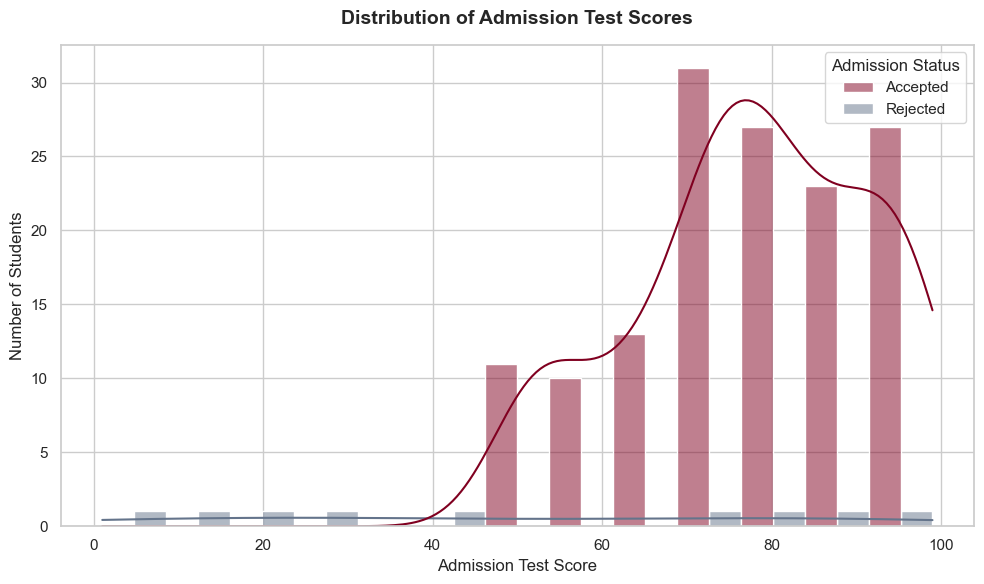

In [27]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
burgundy_theme = {'Accepted': '#800020', 'Rejected': '#64748b'}
sns.histplot(
    data=df, 
    x='Admission Test Score', 
    hue='Admission Status', 
    multiple='dodge',       
    kde=True,           
    palette=burgundy_theme  
)
plt.title('Distribution of Admission Test Scores', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Admission Test Score', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.tight_layout()
plt.show()

## Age Distribution by Gender and Admission Status

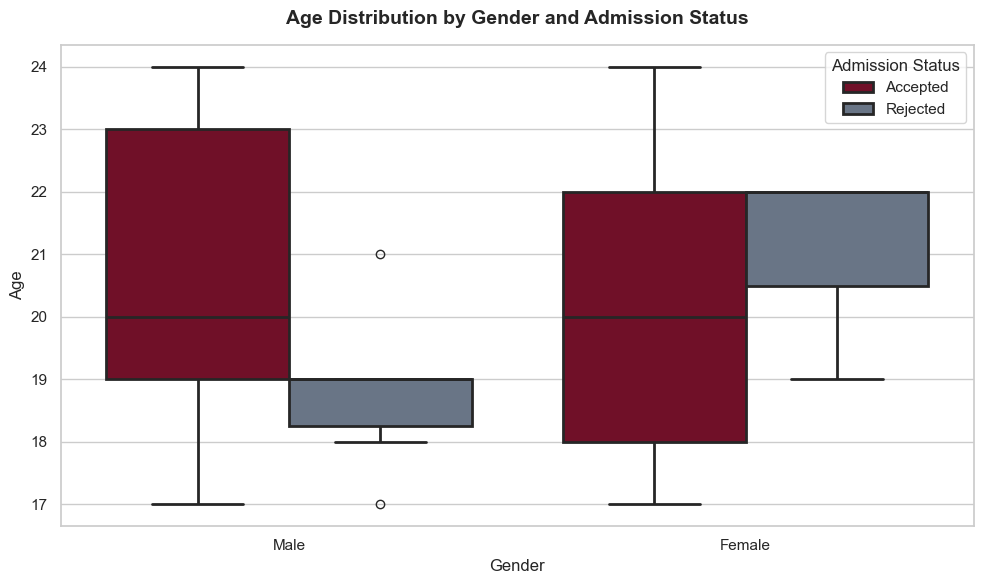

In [28]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
burgundy_theme = {'Accepted': '#800020', 'Rejected': '#64748b'}
sns.boxplot(
    data=df, 
    x='Gender', 
    y='Age', 
    hue='Admission Status', 
    palette=burgundy_theme,   
    linewidth=2
)
plt.title('Age Distribution by Gender and Admission Status', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Age', fontsize=12)
plt.tight_layout()
plt.show()

## Admission Success Rate Heatmap by City

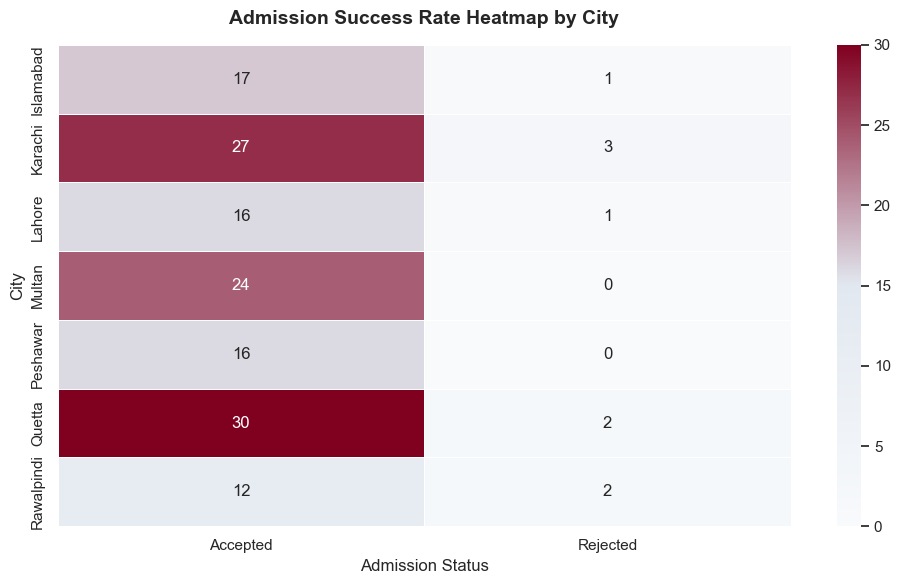

In [29]:
sns.set_theme(style="white")
plt.figure(figsize=(10, 6))
custom_burgundy_cmap = LinearSegmentedColormap.from_list("custom_burgundy", ["#f8fafc", "#e2e8f0", "#800020"])
city_status_cross = pd.crosstab(df['City'], df['Admission Status'])
sns.heatmap(
    city_status_cross, 
    annot=True,             
    fmt="d",                
    cmap=custom_burgundy_cmap,  
    linewidths=.5,          
    cbar=True               
)
plt.title('Admission Success Rate Heatmap by City', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Admission Status', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.tight_layout()
plt.show()

## Overall Admission Success Rate

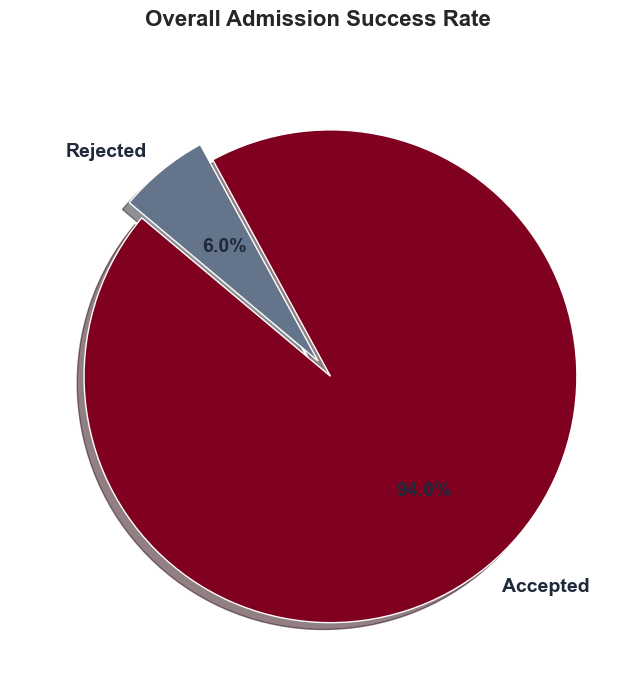

In [30]:
status_counts = df['Admission Status'].value_counts()
plt.figure(figsize=(8, 8))
pie_colors = ['#800020', '#64748b']
plt.pie(
    status_counts, 
    labels=status_counts.index, 
    autopct='%1.1f%%',          
    startangle=140,             
    colors=pie_colors,         
    explode=(0.08, 0),          
    shadow=True,               
    textprops={'fontsize': 14, 'fontweight': 'bold', 'color': '#1e293b'} 
)
plt.title('Overall Admission Success Rate', fontsize=16, fontweight='bold', pad=20)
plt.show()

## College Admissions Analysis Dashboard

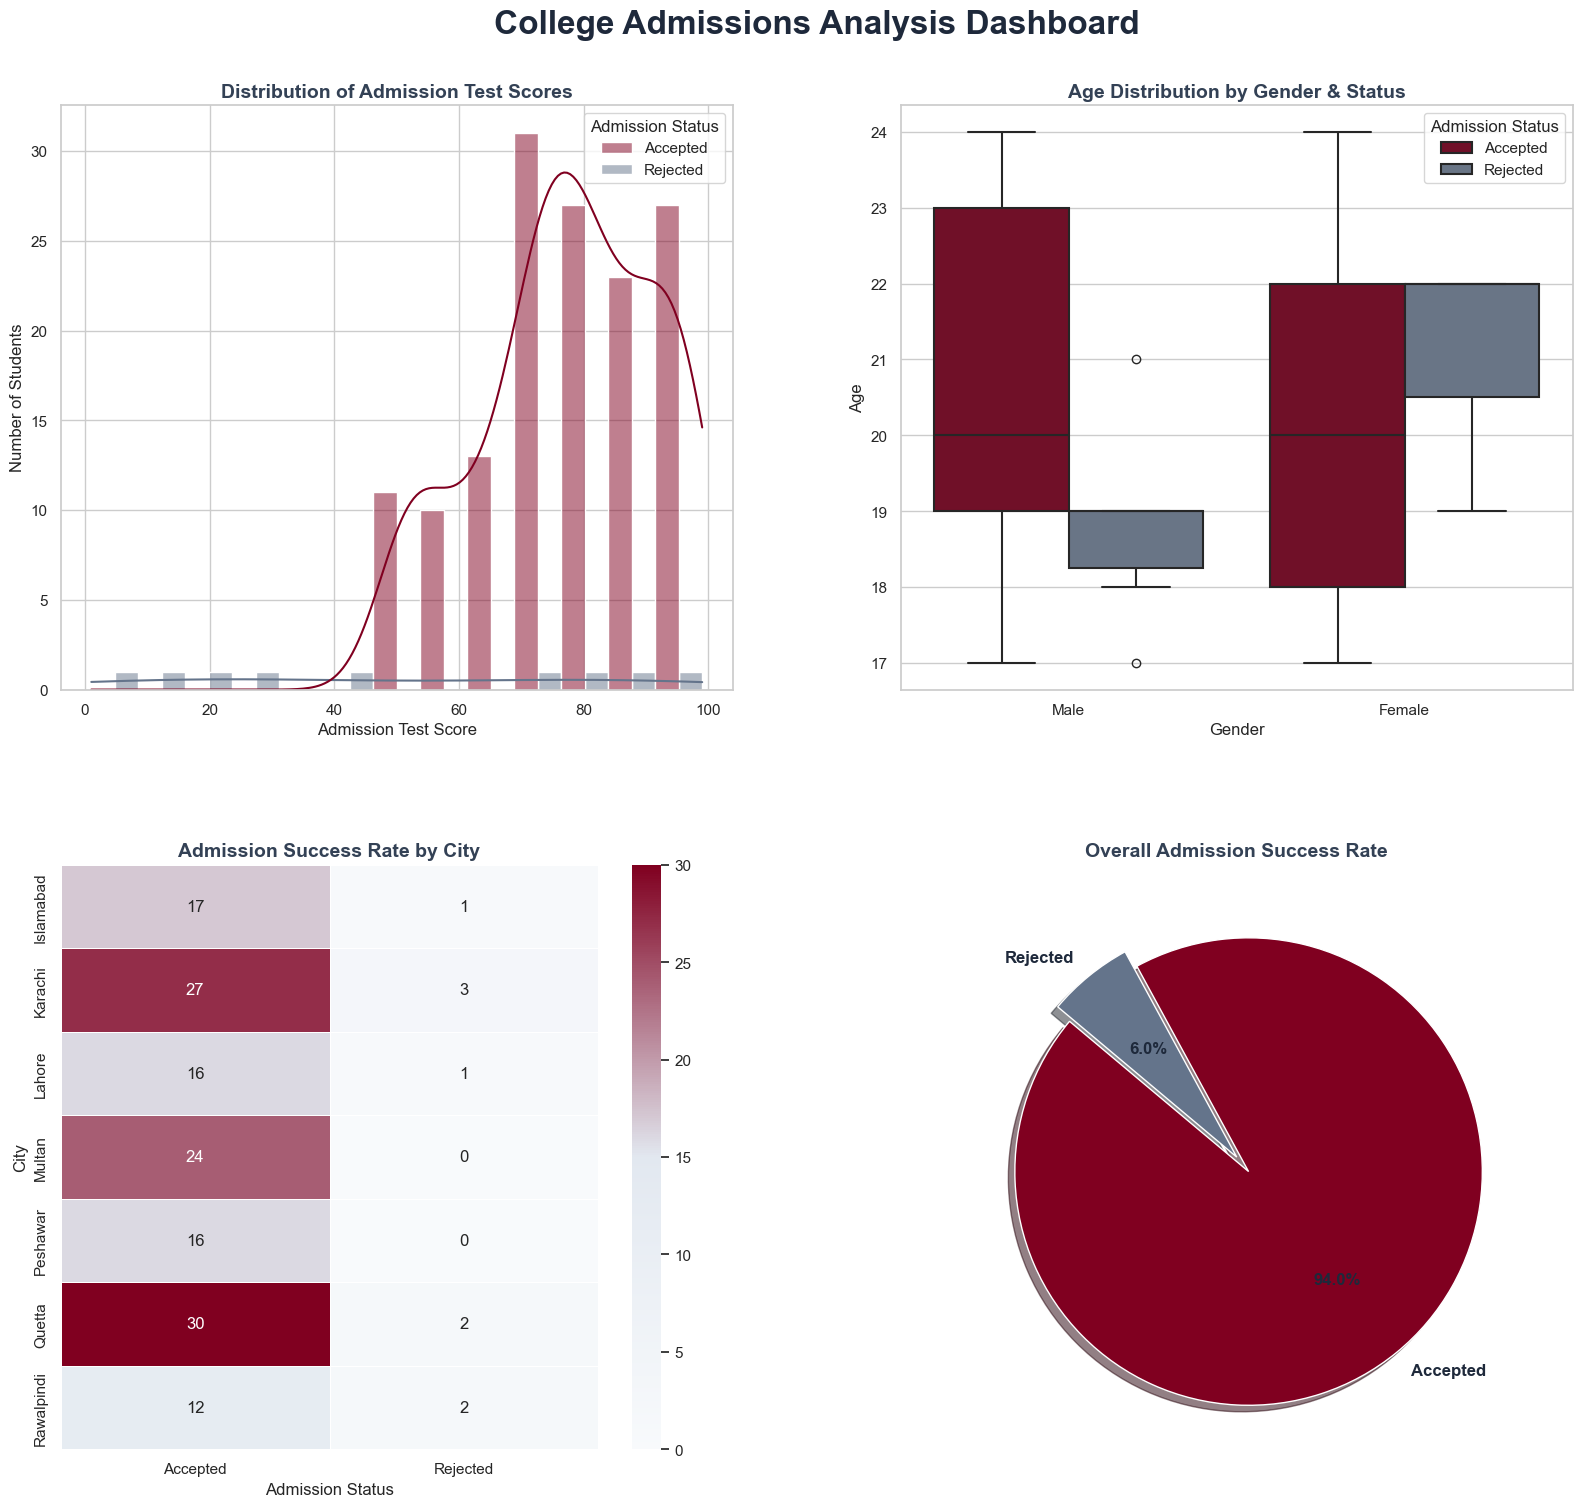

In [31]:
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 16))
fig.suptitle('College Admissions Analysis Dashboard', fontsize=24, fontweight='bold', y=0.98, color='#1e293b')
burgundy_theme = {'Accepted': '#800020', 'Rejected': '#64748b'} 
custom_burgundy_cmap = LinearSegmentedColormap.from_list("custom_burgundy", ["#f8fafc", "#e2e8f0", "#800020"])
sns.histplot(
    data=df, x='Admission Test Score', hue='Admission Status', 
    multiple='dodge', kde=True, ax=ax1, palette=burgundy_theme
)
ax1.set_title('Distribution of Admission Test Scores', fontsize=14, fontweight='bold', color='#334155')
ax1.set_xlabel('Admission Test Score')
ax1.set_ylabel('Number of Students')
sns.boxplot(
    data=df, x='Gender', y='Age', hue='Admission Status', 
    ax=ax2, palette=burgundy_theme, linewidth=1.5
)
ax2.set_title('Age Distribution by Gender & Status', fontsize=14, fontweight='bold', color='#334155')
ax2.set_xlabel('Gender')
ax2.set_ylabel('Age')
city_status_cross = pd.crosstab(df['City'], df['Admission Status'])
sns.heatmap(
    city_status_cross, annot=True, fmt="d", 
    cmap=custom_burgundy_cmap, linewidths=.5, cbar=True, ax=ax3 
)
ax3.set_title('Admission Success Rate by City', fontsize=14, fontweight='bold', color='#334155')
ax3.set_xlabel('Admission Status')
ax3.set_ylabel('City')
status_counts = df['Admission Status'].value_counts()
pie_colors = [burgundy_theme[status] for status in status_counts.index]
ax4.pie(
    status_counts, labels=status_counts.index, autopct='%1.1f%%', 
    startangle=140, colors=pie_colors, explode=(0.08, 0), shadow=True,
    textprops={'fontsize': 12, 'fontweight': 'bold', 'color': '#1e293b'}
)
ax4.set_title('Overall Admission Success Rate', fontsize=14, fontweight='bold', color='#334155')
plt.subplots_adjust(left=0.08, right=0.92, top=0.92, bottom=0.08, wspace=0.25, hspace=0.3)
plt.savefig('admissions_dashboard_perfect_match.png', dpi=300, bbox_inches='tight')
plt.show()